# Spark analysis (PySpark-only)


In [2]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

#LOAD info
spark = SparkSession.builder.appName('F1 Pipeline Notebook')\
    .master('local[*]')\
    .getOrCreate()

# Column name + typing
schema = T.StructType([
    T.StructField('Driver', T.StringType(), True),                   # Nom du pilote # Identifier
    T.StructField('LapNumber', T.IntegerType(), True),               # Numéro du tour # Identifier
    T.StructField('Compound', T.StringType(), True),                 # Type de pneu (Soft, Medium, Hard)
    T.StructField('Stint', T.IntegerType(), True),                   # Numéro de stint (séquence de tours avec le même pneu) 
    T.StructField('TyreLife', T.DoubleType(), True),                 # Durée de vie du pneu
    T.StructField('Position', T.IntegerType(), True),                # Position du pilote
    T.StructField('LapTime (s)', T.DoubleType(), True),              # Temps du tour (en secondes)
    T.StructField('Race', T.StringType(), True),                     # Nom de la course # Identifier
    T.StructField('Year', T.IntegerType(), True),                    # Année de la course # Identifier
    T.StructField('LapTime_Delta', T.DoubleType(), True),            # Différence de temps par rapport au pilote devant
    T.StructField('Cumulative_Degradation', T.DoubleType(), True),   # Dégradation cumulative du pneu
    T.StructField('PitStop', T.IntegerType(), True),                 # Indicateur de pit stop (1 si le pilote a effectué un pit stop à ce tour, 0 sinon)
    T.StructField('PitNextLap', T.IntegerType(), True),              # Indicateur de pit stop au tour suivant (1 si le pilote effectuera un pit stop au tour suivant, 0 sinon)
    T.StructField('RaceProgress', T.DoubleType(), True),             # Progression de la course (en pourcentage)
    T.StructField('Normalized_TyreLife', T.DoubleType(), True),      # Durée de vie du pneu normalisée par rapport à la durée de vie maximale observée pour ce type de pneu
    T.StructField('Position_Change', T.DoubleType(), True),          # Changement de position par rapport au tour précédent (en nombre de places gagnées ou perdues)
])

csv_path = 'f1_strategy_dataset_v4.csv'
df = spark.read.csv(csv_path, header=True, schema=schema)\
    .withColumnRenamed('LapTime (s)', 'LapTime_s')



In [3]:

# nettoyage 
df = df.filter(F.col('Compound') != 'None')

In [4]:
# header rapide 
# utilisé des drivers distincts
driver_filter = [row['Driver'] for row in df.select('Driver').distinct().collect()][:5]
print("Drivers présents dans le dataset :", driver_filter)
# on partitionne par driver et on ordonne par lap number decroissant pour avoir le dernier tour de chaque driver
w = Window.partitionBy('Driver').orderBy(F.col('LapNumber').desc())
one_row_per_driver = (
    df.filter(F.col('Driver').isin(driver_filter))
      .withColumn('rn', F.row_number().over(w))
      .filter(F.col('rn') == 1) # permet de prendre la dernière ligne de chaque driver (dernier tour)
      .drop('rn')
)
one_row_per_driver.show(len(driver_filter), truncate=False)




Drivers présents dans le dataset : ['OCO', 'BOT', 'HAM', 'VER', 'ZHO']
+------+---------+------------+-----+--------+--------+---------+-----------------+----+-------------------+----------------------+-------+----------+------------+-------------------+---------------+
|Driver|LapNumber|Compound    |Stint|TyreLife|Position|LapTime_s|Race             |Year|LapTime_Delta      |Cumulative_Degradation|PitStop|PitNextLap|RaceProgress|Normalized_TyreLife|Position_Change|
+------+---------+------------+-----+--------+--------+---------+-----------------+----+-------------------+----------------------+-------+----------+------------+-------------------+---------------+
|BOT   |77       |INTERMEDIATE|2    |26.0    |11      |84.139   |Monaco Grand Prix|2023|-0.4980000000000046|-8.015                |0      |0         |1.0         |1.0                |0.0            |
|HAM   |78       |INTERMEDIATE|3    |24.0    |4       |85.105   |Monaco Grand Prix|2023|-1.1049999999999898|-14.49799999999999   

In [5]:
# SHOW INFO

# Affiche les meilleurs tours par pilote (meilleur = temps minimal).
# On récupère tous les pilotes triés par meilleur tour
# on convertit en pandas et on affiche tout dans le terminal. (meilleur affichage)
print('-----------------------\nMeilleurs tours par pilote (tous les pilotes, triés par BestLap) :')
best_laps = df.groupBy('Driver')\
    .agg(F.min('LapTime_s').alias('BestLap'))\
    .orderBy('BestLap')
    
# pandas pour lisibilité 
best_laps_pdf = best_laps.toPandas()
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)
best_laps_pdf['BestLap'] = best_laps_pdf['BestLap'].round(3)
print(best_laps_pdf.to_string(index=False))



-----------------------
Meilleurs tours par pilote (tous les pilotes, triés par BestLap) :
Driver  BestLap
   VER   67.012
   LEC   67.583
   ALO   67.694
   PIA   67.924
   NOR   68.016
   PER   68.111
   STR   68.463
   HAM   68.628
   SAI   68.880
   GAS   69.046
   RUS   69.164
   BOR   69.247
   HUL   69.459
   OCO   69.550
   ALB   69.560
   SAR   69.611
   TSU   69.620
   COL   69.621
   ZHO   69.786
   DEV   69.852
   BOT   69.940
   BEA   69.960
   LAW   69.977
   MAG   70.125
   HAD   70.204
   RIC   70.426
   VET   70.467
   MSC   70.479
   LAT   70.890
   ANT   73.123
   DOO   89.121


In [6]:
# Transfo

df.sort('LapNumber', ascending=True).groupBy('Driver','Race','Year')

#normalisations en pourcentage pour RaceProgress
df = df.withColumn('RaceProgress_norm',
                   F.when(F.col('RaceProgress') > 1, F.col('RaceProgress')/100.0)
                    .otherwise(F.col('RaceProgress')))

df.show(5)

w_2 = Window \
    .partitionBy('Driver', 'Race', 'Year') \
    .orderBy('LapNumber')
    
df = df.withColumn(
    'prev_LapTime',
    F.lag('LapTime_s').over(w_2)
)

df = df.withColumn(
    'Delta_LapTime_with_previous',
    F.col('LapTime_s') - F.col('prev_LapTime')
)

df.show(5)
# ajoutez le previous lap time 
# df.withColumn('prev_LapTime', F.lag('LapTime_s'))

+------+---------+--------+-----+--------+--------+---------+--------------------+----+-------------------+----------------------+-------+----------+------------------+-------------------+---------------+------------------+
|Driver|LapNumber|Compound|Stint|TyreLife|Position|LapTime_s|                Race|Year|      LapTime_Delta|Cumulative_Degradation|PitStop|PitNextLap|      RaceProgress|Normalized_TyreLife|Position_Change| RaceProgress_norm|
+------+---------+--------+-----+--------+--------+---------+--------------------+----+-------------------+----------------------+-------+----------+------------------+-------------------+---------------+------------------+
|   ALB|        1|  MEDIUM|    1|     2.0|      17|  100.625|Abu Dhabi Grand Prix|2023|                0.0|                   0.0|      0|         0|0.0172413793103448| 0.1176470588235294|            0.0|0.0172413793103448|
|   ALB|        2|  MEDIUM|    1|     3.0|      18|    93.56|Abu Dhabi Grand Prix|2023| -7.0649999999999

In [7]:
# pour chaque niveau d'usure (Compound) voir la moyenne du delta lap time avec le tour précédent
# on exclut les valeurs nulles, on calcule la moyenne et on affiche en pandas pour lisibilité
avg_delta_by_compound = (
    df.filter(F.col('Delta_LapTime_with_previous').isNotNull())
        .filter(F.col('Compound').isNotNull())
        .groupBy('Compound')
        .agg(F.mean('Delta_LapTime_with_previous').alias('AvgDeltaLapTime'))
        .orderBy('AvgDeltaLapTime')
)

# conversion pandas pour affichage soigné
try:
    avg_delta_pdf = avg_delta_by_compound.toPandas()
    avg_delta_pdf['AvgDeltaLapTime'] = avg_delta_pdf['AvgDeltaLapTime'].round(4)
    print(avg_delta_pdf.to_string(index=False))
except Exception as e:
    print('Conversion toPandas failed:', e)
    avg_delta_by_compound.show(50, truncate=False)


    Compound  AvgDeltaLapTime
         WET          -3.7608
INTERMEDIATE          -0.8804
      MEDIUM          -0.6876
        HARD          -0.6313
        SOFT          -0.5073


In [8]:
# pour chaque niveau d'usure (Compound) voir combien de temps necessaire avant un changement de pneu
# (voir diff entre pitNextLap ou PitStop le Stint)

# partionner par les uniques de courses et le stint 
w_stint = Window.partitionBy('Driver', 'Race', 'Year', 'Stint').orderBy('LapNumber')
df2 = df.withColumn('lap_in_stint', F.row_number().over(w_stint))

# 2) longueur du stint (nombre de tours avec le même pneu)
stint_lengths = (
    df2.groupBy('Driver', 'Race', 'Year', 'Stint', 'Compound')
       .agg(F.max('lap_in_stint').alias('Stint_Laps'))
)

# stint length moyen
avg_stint_length = stint_lengths.groupBy('Compound')\
    .agg(F.mean('Stint_Laps').alias('Avg_Stint_Laps'))\
    .orderBy('Avg_Stint_Laps')
    
print('-----------------------\nLongueur moyenne des stints par compound :')
avg_stint_length.show(truncate=False)

# 3) stats par compound (moyenne, médiane, min/max, std, nombres de stints)
compound_stats = (
    stint_lengths.groupBy('Compound')
                 .agg(
                     F.mean('Stint_Laps').alias('avg_laps'),
                     F.expr('percentile_approx(Stint_Laps, 0.5)').alias('median_laps'),
                     F.expr('percentile_approx(Stint_Laps, array(0.25,0.75))').alias('iqr_quartiles'),
                     F.min('Stint_Laps').alias('min_laps'),
                     F.max('Stint_Laps').alias('max_laps'),
                     F.stddev('Stint_Laps').alias('stddev_laps'),
                     F.count('*').alias('num_stints')
                 )
                 .orderBy('avg_laps')
)

try:
    pdf = compound_stats.toPandas()
    pd.set_option('display.width', 200)
    pdf['avg_laps'] = pdf['avg_laps'].round(2)
    pdf['median_laps'] = pdf['median_laps'].astype(int)
    print('-----------------------\nStats détaillées des stints par compound :')
    print(pdf.to_string(index=False))
except Exception as e:
    print('toPandas failed:', e)
    compound_stats.show(truncate=False)


-----------------------
Longueur moyenne des stints par compound :
+------------+------------------+
|Compound    |Avg_Stint_Laps    |
+------------+------------------+
|WET         |8.3125            |
|SOFT        |13.659163987138264|
|INTERMEDIATE|15.263736263736265|
|MEDIUM      |18.660882498760536|
|HARD        |25.622222222222224|
+------------+------------------+

-----------------------
Stats détaillées des stints par compound :
    Compound  avg_laps  median_laps iqr_quartiles  min_laps  max_laps  stddev_laps  num_stints
         WET      8.31            4       [2, 17]         1        21     7.671878          48
        SOFT     13.66           14       [8, 19]         1        50     8.206928         933
INTERMEDIATE     15.26           13       [7, 25]         1        44    10.720938         364
      MEDIUM     18.66           18      [12, 25]         1        76    10.229947        2017
        HARD     25.62           25      [18, 33]         1        76    12.209697  

In [9]:
# voir pour chaque Pilote, qui malméne le mieux ses pneus
# (en moyenne, qui a le delta lap time le plus élevé avec le tour précédent)
# On exclut les tours liés aux pitstops et les prev null pour éviter biais

driver_filter_df = (
    df.filter(
        (F.col('Delta_LapTime_with_previous').isNotNull()) &
        (F.col('prev_LapTime').isNotNull()) &
        (F.col('PitStop') == 0)
    )
)

driver_abuse = (
    driver_filter_df.groupBy('Driver')
    .agg(
        F.mean('Delta_LapTime_with_previous').alias('avg_delta'),
        # mesures de dispersion pour voir la variabilité du delta (certains pilotes peuvent avoir des pics de dégradation)
        F.stddev('Delta_LapTime_with_previous').alias('stddev_delta'),
        F.count('*').alias('n_samples')
    )
    .filter(F.col('n_samples') >= 10)
    .orderBy(F.col('avg_delta').desc())
)

print('Top pilotes par dégradation moyenne (delta vs tour précédent) :')
try:
    pd.set_option('display.width', 200)
    print(driver_abuse.toPandas().round(4).to_string(index=False))
except Exception:
    driver_abuse.show(50, truncate=False)


Top pilotes par dégradation moyenne (delta vs tour précédent) :
Driver  avg_delta  stddev_delta  n_samples
   ANT    -0.1766        6.4002        879
   HAD    -0.2433        5.9184        828
   MSC    -0.2452        8.7228        725
   VER    -0.3063        6.8282       3871
   BOR    -0.3094        6.1305        845
   COL    -0.3111        5.7022       1141
   LAT    -0.3725        8.3904        689
   PER    -0.4094        6.9130       2836
   ALB    -0.4315        7.0133       3462
   MAG    -0.4358        7.2331       2727
   RIC    -0.4394        6.4905       1978
   VET    -0.4475        7.5976        642
   OCO    -0.4506        7.6607       3577
   BEA    -0.4788        7.0496       1077
   BOT    -0.4975        6.8557       2774
   HUL    -0.5345        7.2476       3059
   LAW    -0.5396        7.3462       1356
   TSU    -0.5554        7.3024       3625
   DEV    -0.5801        7.6194        632
   DOO    -0.5951        6.5817        184
   HAM    -0.9121       39.1051  

In [10]:
driver_compound = (
    driver_filter_df.groupBy('Driver', 'Compound')
    .agg(F.mean('Delta_LapTime_with_previous').alias('avg_delta_compound'),
         F.count('*').alias('n_samples_compound'))
)

# Pivot pour voir rapidement les composés côte‑à‑côte
driver_compound_pivot = (
    driver_compound.filter(F.col('n_samples_compound') >= 5)  
    .groupBy('Driver')
    .pivot('Compound')
    .agg(F.first('avg_delta_compound'))
    .orderBy(F.desc('Hard')) 
)

print('\nComparaison pilote x compound (valeurs moyennes de delta) :')
try:
    print(driver_compound_pivot.toPandas().round(4).to_string(index=False))
except Exception:
    driver_compound_pivot.show(50, truncate=False)



Comparaison pilote x compound (valeurs moyennes de delta) :
Driver    HARD  INTERMEDIATE  MEDIUM    SOFT      WET
   MSC  0.4285       -0.0540 -0.6493 -0.5768      NaN
   LAT  0.3302       -4.2519  0.0811 -1.2171      NaN
   HAD -0.0088       -7.9101 -0.3286 -0.2839      NaN
   ANT -0.0898       -0.6136 -0.0979 -0.5121      NaN
   COL -0.0974       -1.8525 -0.2527 -1.2496      NaN
   BOR -0.1745       -2.2093 -0.3137 -0.1599      NaN
   STR -0.1857       -1.1718 -2.2516 -0.6402      NaN
   MAG -0.2084       -0.5475 -0.5506 -1.0737  -2.1245
   VET -0.2272        0.0868 -0.0492 -3.6049      NaN
   BEA -0.2278       -1.0472 -0.4083 -1.1510      NaN
   RUS -0.2345       -0.8471 -1.8367 -0.4656  -1.3285
   RIC -0.2389       -0.6888 -0.4374 -1.1003   1.8202
   ALB -0.2523       -1.0711 -0.4255 -0.6712  -3.9427
   ALO -0.2565       -1.5948 -1.9242 -1.2010  -2.7392
   VER -0.2612       -1.0621 -0.1520 -0.6095   2.9722
   HUL -0.2629       -0.7918 -0.4959 -1.3815  -0.6116
   GAS -0.2874       

# Visualisations

Visualisations exploratoires (**matplotlib**) ajoutées en complément des analyses ci-dessus. Elles réutilisent les DataFrames déjà calculés (`df`, `df2`, `stint_lengths`, `compound_stats`, `driver_abuse`, `driver_compound_pivot`) **sans modifier le code existant**.

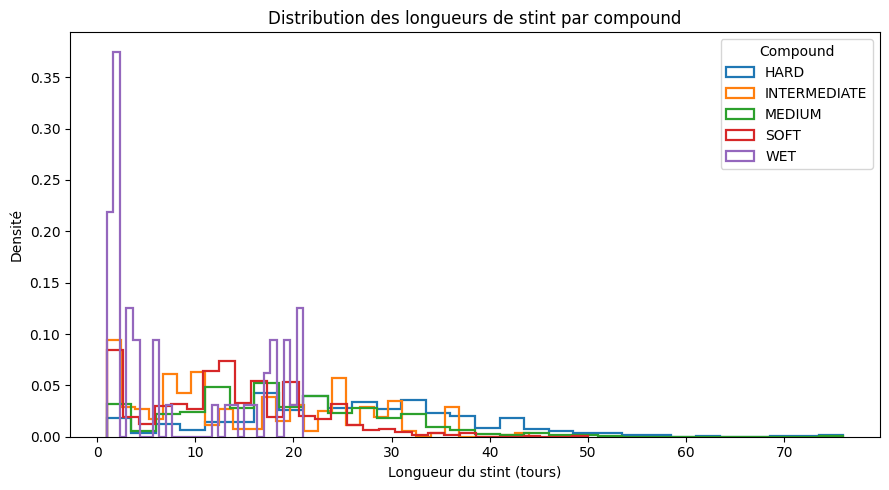

In [11]:
# --- Viz 1 : Histogramme des longueurs de stint par compound ---
# Distribution des durées de stint (en tours) pour chaque type de gomme.
# On normalise en densité (density=True) pour comparer des compounds aux effectifs différents.
pdf = stint_lengths.select('Compound', 'Stint_Laps').toPandas()

fig, ax = plt.subplots(figsize=(9, 5))
for compound in sorted(pdf['Compound'].unique()):
    serie = pdf[pdf['Compound'] == compound]['Stint_Laps']
    ax.hist(serie, bins=30, histtype='step', density=True, linewidth=1.6, label=compound)
ax.set_title('Distribution des longueurs de stint par compound')
ax.set_xlabel('Longueur du stint (tours)')
ax.set_ylabel('Densité')
ax.legend(title='Compound')
plt.tight_layout()
plt.show()

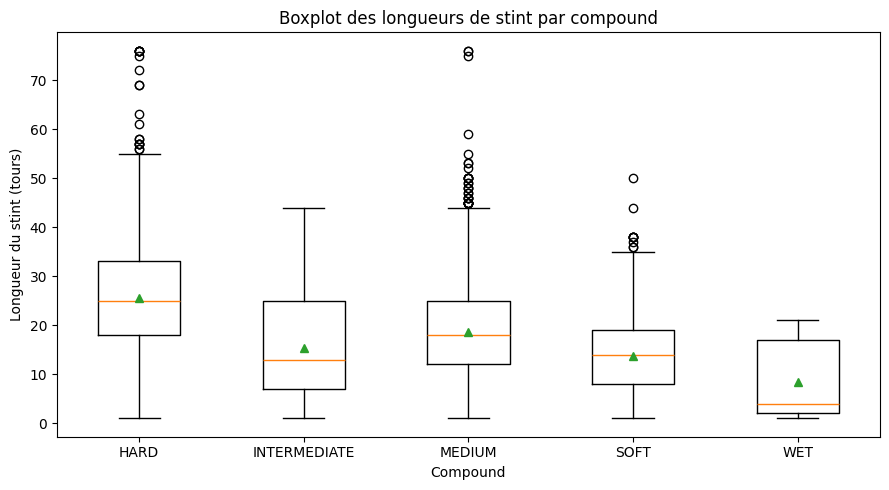

In [12]:
# --- Viz 2 : Boxplot comparatif des Stint_Laps par compound ---
# Médiane, IQR (boîte) et outliers (points) pour chaque gomme.
# Réutilise le DataFrame pandas `pdf` calculé à la Viz 1.
compounds = sorted(pdf['Compound'].unique())
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([pdf[pdf['Compound'] == c]['Stint_Laps'] for c in compounds],
           tick_labels=compounds, showmeans=True)
ax.set_title('Boxplot des longueurs de stint par compound')
ax.set_xlabel('Compound')
ax.set_ylabel('Longueur du stint (tours)')
plt.tight_layout()
plt.show()

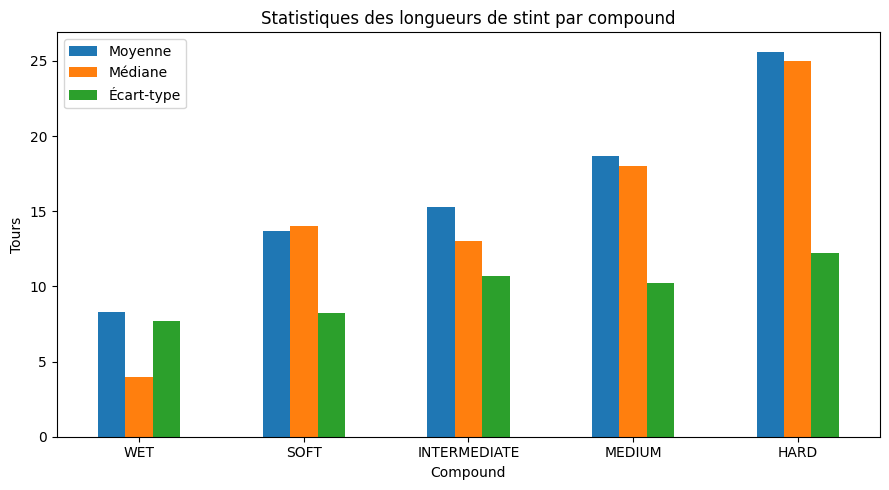

In [13]:
# --- Viz 3 : Bar chart des statistiques agrégées par compound ---
# Résumé rapide : moyenne / médiane / écart-type des longueurs de stint.
stats = compound_stats.toPandas().set_index('Compound')
ax = stats[['avg_laps', 'median_laps', 'stddev_laps']].plot.bar(rot=0, figsize=(9, 5))
ax.set_title('Statistiques des longueurs de stint par compound')
ax.set_xlabel('Compound')
ax.set_ylabel('Tours')
ax.legend(['Moyenne', 'Médiane', 'Écart-type'])
plt.tight_layout()
plt.show()

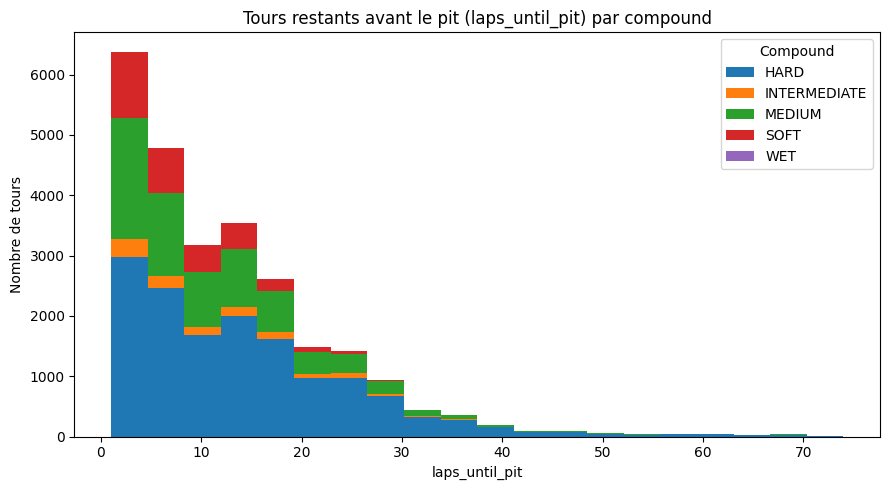

In [14]:
# --- Viz 4 : Histogramme des laps_until_pit (validation de PitNextLap) ---
# On reconstruit `df_join` en associant à chaque tour la longueur totale de son stint,
# puis on calcule combien de tours restent avant le pit (laps_until_pit) sur les tours
# marqués PitNextLap == 1. Distribution attendue : surtout de petites valeurs.
df_join = df2.join(
    stint_lengths,
    on=['Driver', 'Race', 'Year', 'Stint', 'Compound'],
    how='inner'
)
pdf2 = (
    df_join.filter('PitNextLap == 1')
           .withColumn('laps_until_pit', F.col('Stint_Laps') - F.col('lap_in_stint') + 1)
           .select('Compound', 'laps_until_pit')
           .toPandas()
)

compounds = sorted(pdf2['Compound'].unique())
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist([pdf2[pdf2['Compound'] == c]['laps_until_pit'] for c in compounds],
        bins=20, stacked=True, label=compounds)
ax.set_title('Tours restants avant le pit (laps_until_pit) par compound')
ax.set_xlabel('laps_until_pit')
ax.set_ylabel('Nombre de tours')
ax.legend(title='Compound')
plt.tight_layout()
plt.show()

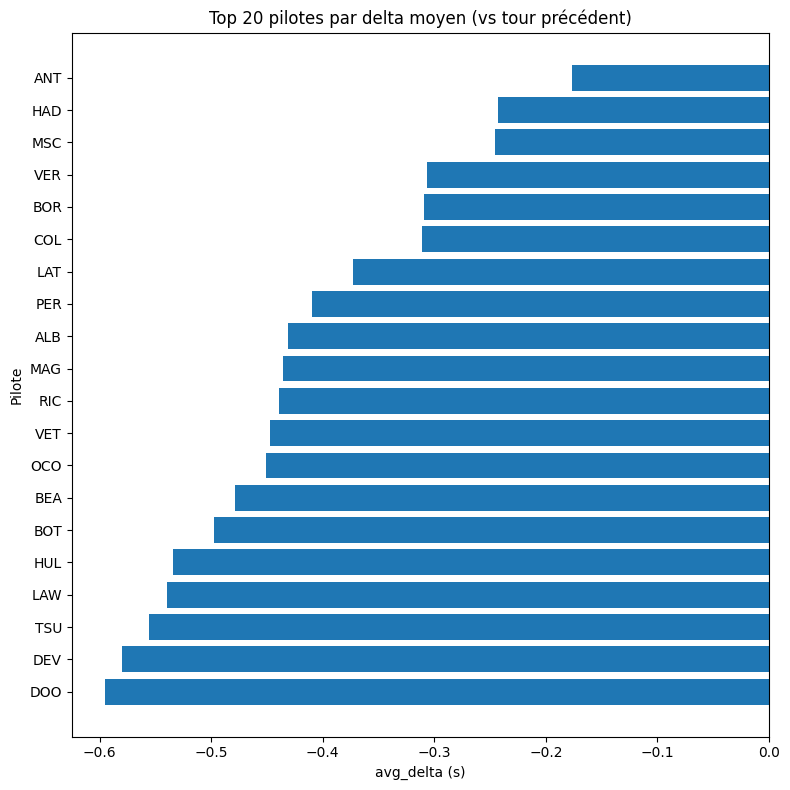

In [15]:
# --- Viz 5 : Classement pilotes — bar chart de l'avg_delta ---
# Qui « malmène » le plus ses pneus en moyenne (delta de temps vs tour précédent).
# Top 20 pilotes ordonnés par avg_delta décroissant.
top = driver_abuse.orderBy(F.col('avg_delta').desc()).limit(20).toPandas()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top['Driver'], top['avg_delta'])
ax.invert_yaxis()  # plus grand avg_delta en haut
ax.set_title('Top 20 pilotes par delta moyen (vs tour précédent)')
ax.set_xlabel('avg_delta (s)')
ax.set_ylabel('Pilote')
plt.tight_layout()
plt.show()

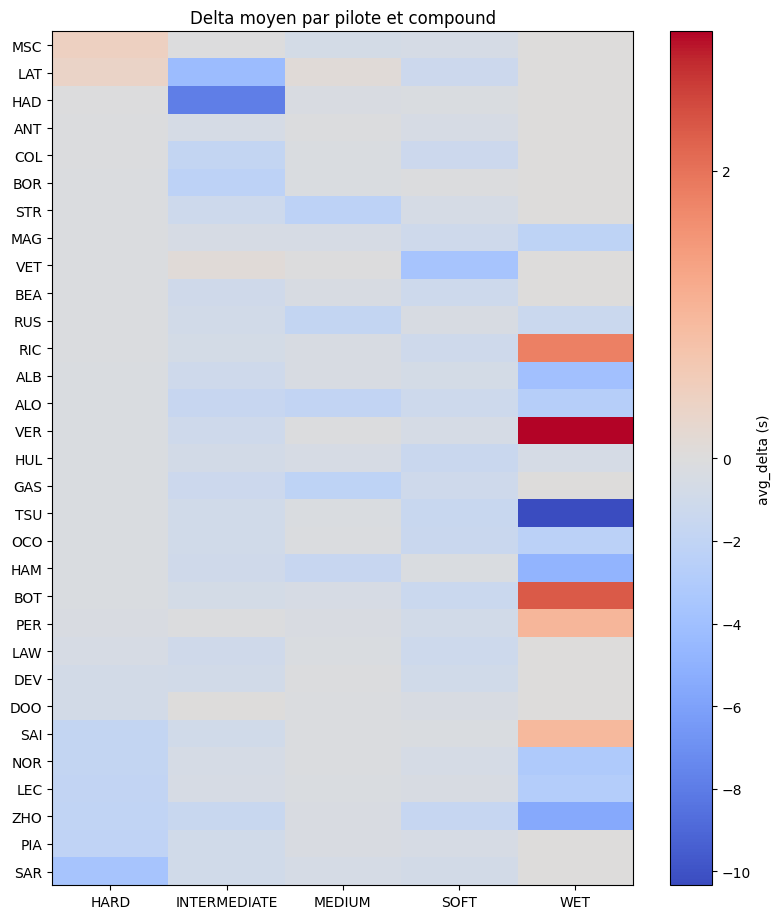

In [16]:
# --- Viz 6 : Heatmap pilote x compound (delta moyen) ---
# Met en évidence les pilotes sensibles selon le type de gomme.
# Échelle divergente centrée sur 0 (rouge = delta positif, bleu = négatif).
import matplotlib.colors as mcolors

mat = driver_compound_pivot.toPandas().set_index('Driver').fillna(0)

fig, ax = plt.subplots(figsize=(8, max(6, 0.3 * len(mat))))
im = ax.imshow(mat.values, cmap='coolwarm', aspect='auto',
               norm=mcolors.TwoSlopeNorm(vcenter=0))
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
ax.set_title('Delta moyen par pilote et compound')
fig.colorbar(im, ax=ax, label='avg_delta (s)')
plt.tight_layout()
plt.show()

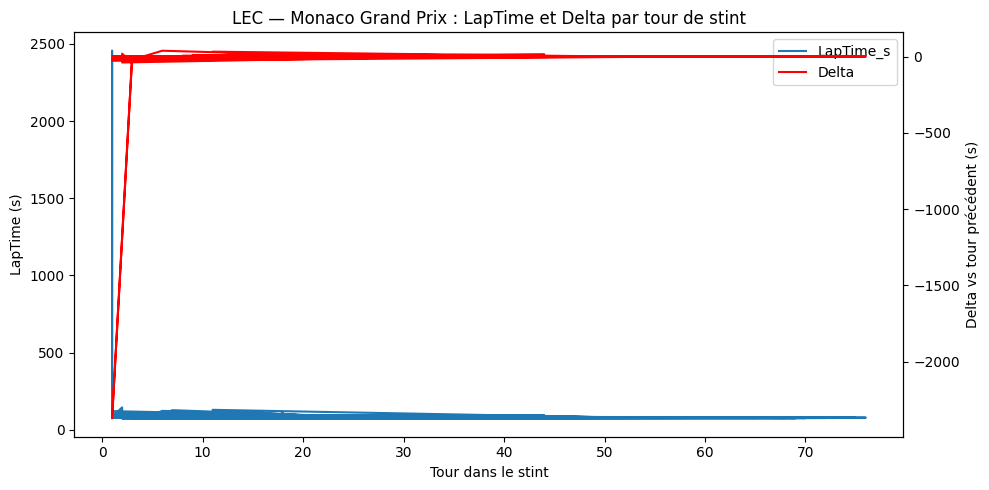

In [17]:
# --- Viz 7 : Time-series d'un pilote sur ses stints (LapTime & Delta) ---
# Visualise la dégradation intra-stint : LapTime_s (axe gauche) et Delta (axe droit).
# NB : pilotes en abréviation (LEC) et courses en nom complet (Monaco Grand Prix).
sample = (
    df2.filter("Driver == 'LEC' AND Race == 'Monaco Grand Prix'")
       .orderBy('LapNumber')
       .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
l1, = ax.plot(sample['lap_in_stint'], sample['LapTime_s'], label='LapTime_s')
ax.set_xlabel('Tour dans le stint')
ax.set_ylabel('LapTime (s)')

ax2 = ax.twinx()
l2, = ax2.plot(sample['lap_in_stint'], sample['Delta_LapTime_with_previous'],
               color='r', label='Delta')
ax2.set_ylabel('Delta vs tour précédent (s)')

ax.set_title('LEC — Monaco Grand Prix : LapTime et Delta par tour de stint')
ax.legend(handles=[l1, l2], loc='best')
plt.tight_layout()
plt.show()

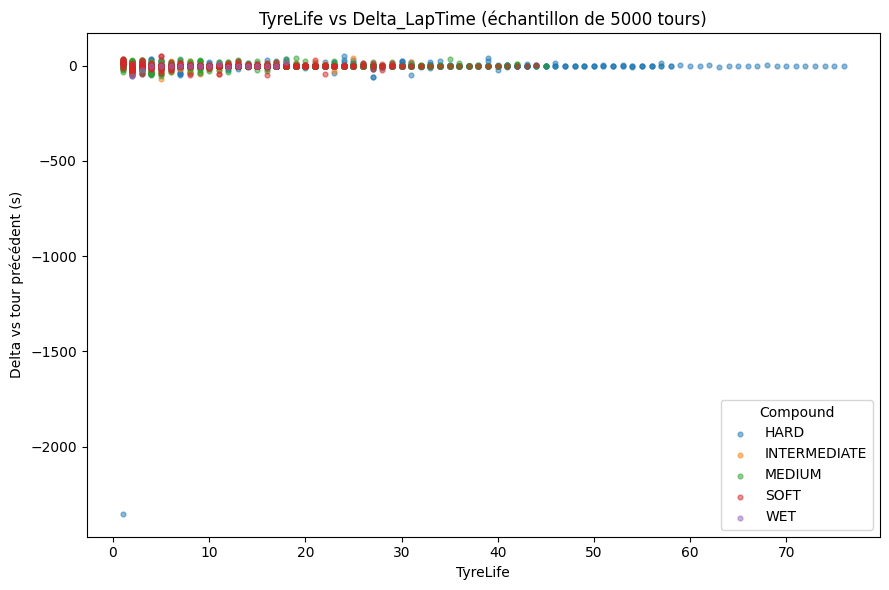

In [18]:
# --- Viz 8 : Scatter TyreLife vs Delta (couleur par compound) ---
# Relation entre l'usure déclarée du pneu (TyreLife) et la perte de performance (Delta).
# Échantillonnage (limit 5000) avant toPandas() pour rester léger.
samp = (
    df.filter(F.col('TyreLife').isNotNull())
      .select('TyreLife', 'Delta_LapTime_with_previous', 'Compound')
      .limit(5000)
      .toPandas()
)

fig, ax = plt.subplots(figsize=(9, 6))
for compound in sorted(samp['Compound'].dropna().unique()):
    s = samp[samp['Compound'] == compound]
    ax.scatter(s['TyreLife'], s['Delta_LapTime_with_previous'],
               alpha=0.5, s=12, label=compound)
ax.set_title('TyreLife vs Delta_LapTime (échantillon de 5000 tours)')
ax.set_xlabel('TyreLife')
ax.set_ylabel('Delta vs tour précédent (s)')
ax.legend(title='Compound')
plt.tight_layout()
plt.show()

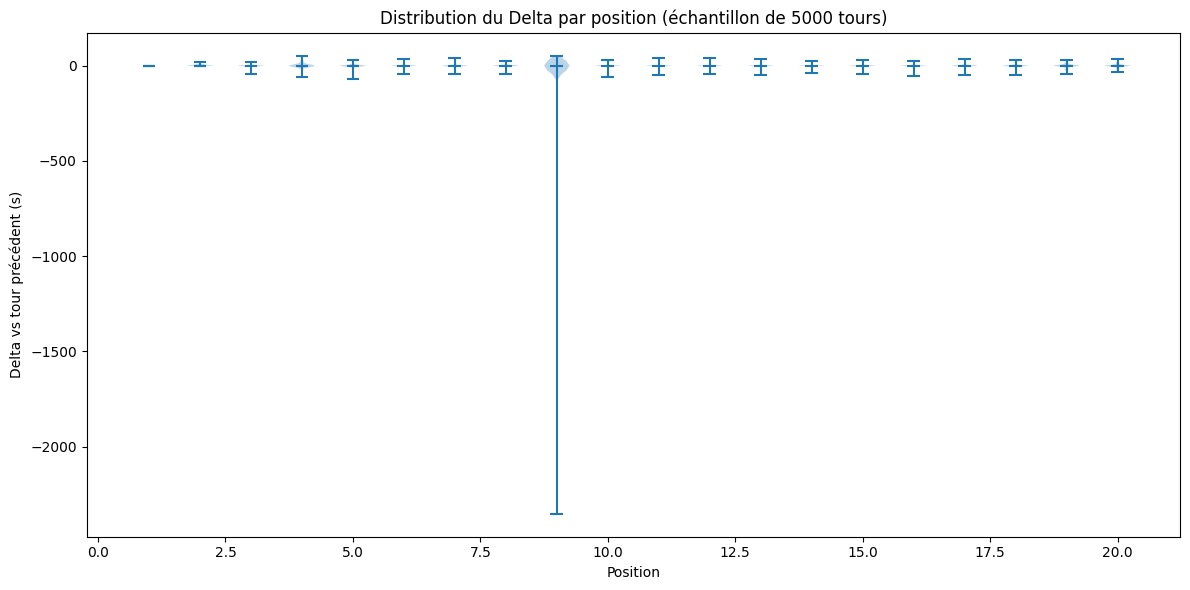

In [19]:
# --- Viz 9 : Violin des Delta par position de course ---
# Voit si le trafic / la position en piste influence la dégradation (delta).
# Échantillonnage (limit 5000) avant toPandas().
samp2 = (
    df.filter("Position IS NOT NULL AND Delta_LapTime_with_previous IS NOT NULL")
      .select('Position', 'Delta_LapTime_with_previous')
      .limit(5000)
      .toPandas()
)

positions = sorted(samp2['Position'].unique())
data = [samp2[samp2['Position'] == p]['Delta_LapTime_with_previous'].values for p in positions]

fig, ax = plt.subplots(figsize=(12, 6))
ax.violinplot(data, positions=positions, showmedians=True)
ax.set_title('Distribution du Delta par position (échantillon de 5000 tours)')
ax.set_xlabel('Position')
ax.set_ylabel('Delta vs tour précédent (s)')
plt.tight_layout()
plt.show()

In [20]:
# --- Conseils pratiques & export CSV (à décommenter au besoin) ---
# - Toujours échantillonner (.limit() ou .sample()) avant toPandas() pour les
#   graphiques à grain fin (<= 5000 lignes), comme fait dans les Viz 7/8/9.
# - Ajouter des filtres (Race, Year, Driver) pour des vues plus lisibles et des
#   comparaisons par contexte.
# - Sauvegarder les tables clés en CSV pour réutilisation :
# compound_stats.toPandas().to_csv('compound_stats.csv', index=False)
# driver_abuse.toPandas().to_csv('driver_abuse.csv', index=False)
# stint_lengths.toPandas().to_csv('stint_lengths.csv', index=False)